# 06. epitope potential（絶対量・射影順序を修正した版）

## なぜ作り直すか

`notebooks/archive/01_epitope_potential.ipynb` の計算には**射影順序の誤り**がある
（`docs/negative_result_cross_cell_transfer.md` 末尾、2026-07-29 発見）。

律速ロジック（ステップ間 min）は発現**レベル**に対して定義されているのに、
**変化量 Δ(z-score)** に適用していた。Δ に min を掛けると「最も下がったステップ」を拾うが、
それは律速ステップではない。射影は非線形なので「先に引く」と「後で引く」は一致しない。

```
誤: Δ発現 → max/min射影 → Δエピトープ
正: 処理後レベル → 射影 → エピトープ量(処理後)
    対照レベル   → 射影 → エピトープ量(対照)
    差を取る    → Δエピトープ
```

## このノートでやること

1. 絶対量（処理後・対照）を**レベルのまま射影**して Δエピトープを出す
2. **誤った順序と突き合わせ**、どれだけ結果が変わるかを測る
3. エピトープごとに「**検出閾値（2倍）を越えて動かす薬が何本あるか**」を数え、候補表にする

判定は他の遺伝子との順位比較ではなく**絶対的な効果量**で行う（`docs/wet_target_selection.md`）。

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

ROOT = Path.cwd()
while not (ROOT / 'data').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
FIGDIR = ROOT / 'results' / 'figures'
TABDIR = ROOT / 'results' / 'tables'
TABDIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    """成果物ごとのフォルダに PNG/PDF/SVG を保存する"""
    outdir = FIGDIR / name
    outdir.mkdir(parents=True, exist_ok=True)
    for ext in ('png', 'pdf', 'svg'):
        plt.savefig(outdir / f'{name}.{ext}', dpi=200, bbox_inches='tight')

print(ROOT)

/Users/koreedatatsuya/research/glyco_epitope_3rd_paper


## 1. 辞書（epitope → step → gene）

In [2]:
steps = pd.read_csv(ROOT / 'data/processed/epitope_step_gene.csv')
print(f"{len(steps)}行 / {steps.EPITOPE_NAME.nunique()}エピトープ / {steps.HGNC_SYMBOL.nunique()}遺伝子")
print(steps.groupby('EPITOPE_NAME').STEP_ID.nunique().value_counts().rename('エピトープ数').to_frame().T)

98行 / 52エピトープ / 57遺伝子
STEP_ID   1  2
エピトープ数   44  8


## 2. 絶対量レベルの読み込み

- 処理後: `abs_glyco_16cell_24h.parquet`（cp_predicted gctx から抽出、24h）
- 対照:   `ctl_glyco_baseline.csv`（DMSO/vector の対照サンプル）

In [3]:
trt = pd.read_parquet(ROOT / 'data/processed/abs_glyco_16cell_24h.parquet')
META = ['cell', 'pertname', 'timepoint', 'dose', 'idx']
GENES = [c for c in trt.columns if c not in META]

ctl = pd.read_csv(ROOT / 'data/processed/ctl_glyco_baseline.csv', low_memory=False)
ctl['cell'] = ctl.SAMPLE_ID.str.split('_').str[1]

common = [g for g in GENES if g in ctl.columns]
steps = steps[steps.HGNC_SYMBOL.isin(common)]
CELLS = sorted(set(trt.cell) & set(ctl.cell))

print(f"処理後 {len(trt):,}試料 / 対照 {len(ctl):,}試料 / 共通遺伝子 {len(common)}")
print(f"辞書（共通遺伝子に限定後）: {steps.EPITOPE_NAME.nunique()}エピトープ / {steps.HGNC_SYMBOL.nunique()}遺伝子")
print(f"対照が取れる細胞 {len(CELLS)}: {', '.join(CELLS)}")

処理後 69,918試料 / 対照 6,400試料 / 共通遺伝子 385
辞書（共通遺伝子に限定後）: 52エピトープ / 56遺伝子
対照が取れる細胞 16: A375, A549, HA1E, HCC515, HELA, HEPG2, HT29, MCF10A, MCF7, MDAMB231, NPC, PC3, THP1, U2OS, VCAP, YAPC


## 3. 射影

ステップ内 isoenzyme は **max**（冗長性 = OR）、ステップ間は **min**（律速 = AND）。
出典 GlycoMaple (Huang et al., Dev Cell 2021)、ステップ分割は GlycoEnzOnto (Groth et al. 2022, CC-BY-4.0)。

複製の要約は**遺伝子レベルで済ませてから射影する**（max はノイズを上振れさせるため、
処理後・対照の両側で同じ扱いにする）。

In [4]:
def project(levels: pd.DataFrame) -> pd.DataFrame:
    """遺伝子レベル(行=サンプル, 列=遺伝子) → エピトープ量(行=サンプル, 列=エピトープ)"""
    out = {}
    for epi, g in steps.groupby('EPITOPE_NAME'):
        per_step = [levels[list(sub.HGNC_SYMBOL.unique())].max(axis=1)
                    for _, sub in g.groupby('STEP_ID')]
        out[epi] = pd.concat(per_step, axis=1).min(axis=1)
    return pd.DataFrame(out)

delta, delta_wrong = {}, {}
for cell in CELLS:
    t = trt[trt.cell == cell].groupby('pertname')[common].mean()
    c = ctl[ctl.cell == cell][common].median()
    delta[cell] = project(t) - project(c.to_frame().T).iloc[0]   # 正: レベル→射影→差
    delta_wrong[cell] = project(t - c)                            # 誤: 差→射影

print({k: v.shape for k, v in list(delta.items())[:3]}, '...')

{'A375': (996, 52), 'A549': (1138, 52), 'HA1E': (1075, 52)} ...


## 4. 順序でどれだけ変わるか

In [5]:
rows = []
for cell in CELLS:
    a, b = delta[cell], delta_wrong[cell]
    for epi in a.columns:
        rows.append(dict(cell=cell, epitope=epi, n_drug=len(a),
                         n_gene=steps[steps.EPITOPE_NAME == epi].HGNC_SYMBOL.nunique(),
                         n_step=steps[steps.EPITOPE_NAME == epi].STEP_ID.nunique(),
                         r=np.corrcoef(a[epi], b[epi])[0, 1],
                         n2x=int((a[epi].abs() >= 1).sum()),
                         n2x_wrong=int((b[epi].abs() >= 1).sum())))
cmp = pd.DataFrame(rows)
cmp.to_csv(TABDIR / 'epitope_projection_order_comparison.csv', index=False)

single = cmp[(cmp.n_gene == 1) & (cmp.n_step == 1)]
multi  = cmp[(cmp.n_gene > 1) | (cmp.n_step > 1)]
print(f"単一遺伝子・単一ステップ: r中央値 {single.r.median():.3f}  （射影が恒等写像なので順序は効かない）")
print(f"複数遺伝子 or 複数ステップ: r中央値 {multi.r.median():.3f}  / r<0.9 が {(multi.r<0.9).mean()*100:.0f}%")
print(f"\n2倍以上動く薬の総数  正 {cmp.n2x.sum():,} / 誤 {cmp.n2x_wrong.sum():,}")

単一遺伝子・単一ステップ: r中央値 1.000  （射影が恒等写像なので順序は効かない）
複数遺伝子 or 複数ステップ: r中央値 0.750  / r<0.9 が 73%

2倍以上動く薬の総数  正 29,759 / 誤 29,038


In [6]:
h = cmp[cmp.cell == 'HEPG2'].set_index('epitope')
print('=== HEPG2: 順序で最も結果が変わるエピトープ ===')
print(h.nsmallest(8, 'r')[['n_gene', 'n_step', 'r', 'n2x', 'n2x_wrong']].round(3).to_string())

=== HEPG2: 順序で最も結果が変わるエピトープ ===
                                               n_gene  n_step      r  n2x  n2x_wrong
epitope                                                                             
Sialyl Lewis x                                      6       2 -0.193    0          0
6'-Sulfo Sialyl Lewis x                             3       2 -0.049    0          0
6,6'- Disulfo Sialyl Lewis x                        3       2 -0.049    0          0
Sialyl 6-Sulfo Lewis x                              3       2 -0.049    0          0
Lewis x                                             4       1  0.192    0         23
Lewis y                                             6       1  0.399    0         32
HNK-1                                               3       1  0.422   38         46
O-Fucose Glycan /Thrombospondin Type 1 Repeat       2       1  0.546    5          4


## 5. 候補表 — 各エピトープを検出閾値以上動かす薬

閾値は統計の p ではなく**アッセイ側**から決める（レクチンフローで見える倍率 = 2倍）。

In [7]:
CELL = 'HEPG2'
d = delta[CELL]
cand = pd.DataFrame({
    'n_gene':  [steps[steps.EPITOPE_NAME == e].HGNC_SYMBOL.nunique() for e in d.columns],
    'n_step':  [steps[steps.EPITOPE_NAME == e].STEP_ID.nunique() for e in d.columns],
    'n_2x':    (d.abs() >= 1).sum(),
    'n_2x_up': (d >= 1).sum(),
    'n_2x_dn': (d <= -1).sum(),
    'max_up':  d.max(),
    'max_dn':  d.min(),
}, index=d.columns).sort_values('n_2x', ascending=False)
cand['pct'] = (100 * cand.n_2x / len(d)).round(1)
cand.index.name = 'epitope'
cand.to_csv(TABDIR / f'epitope_druggability_{CELL.lower()}.csv')
print(f'{CELL}: {len(d)}薬 × {d.shape[1]}エピトープ')
cand.head(15).round(2)

HEPG2: 175薬 × 52エピトープ


,n_gene,n_step,n_2x,n_2x_up,n_2x_dn,max_up,max_dn,pct
epitope,,,,,,,,
T Antigen,1,1,70,70,0,1.50,-0.58,40.0
Chondroitin-4-Sulfate,1,1,49,5,44,1.83,-1.71,28.0
"beta1,6-GlcNAc Branching",1,1,45,41,4,1.71,-1.26,25.7
O-GlcNAc,1,1,44,36,8,1.77,-1.85,25.1
HNK-1,3,1,38,37,1,1.26,-1.04,21.7
GD2,1,1,32,24,8,1.84,-3.07,18.3
N-Acetyl GM2,1,1,32,24,8,1.84,-3.07,18.3
Chondroitin,2,1,19,13,6,2.56,-1.32,10.9
Chondroitin-6-Sulfate,2,1,19,13,6,1.53,-1.65,10.9


In [8]:
# 薬剤 × エピトープの長表（wet依頼の材料。どの薬がどれを動かすか）
long = (d.stack().rename('delta_log2').reset_index()
          .rename(columns={'level_0': 'pertname', 'level_1': 'epitope'}))
long = long[long.delta_log2.abs() >= 1].copy()
long['direction'] = np.where(long.delta_log2 > 0, 'up', 'down')
long['fold'] = (2 ** long.delta_log2).round(2)
long = long.sort_values('delta_log2', key=abs, ascending=False)
long.to_csv(TABDIR / f'drug_epitope_candidates_{CELL.lower()}.csv', index=False)
print(f'閾値(2倍)を越える 薬×エピトープ の組: {len(long):,}')
long.head(12)

閾値(2倍)を越える 薬×エピトープ の組: 522


,pertname,epitope,delta_log2,direction,fold
2789,doxorubicin,N-Acetyl GM2,-3.066656,down,0.12
2770,doxorubicin,GD2,-3.066656,down,0.12
526,azacitidine,Chondroitin,2.560827,up,5.90
386,aspirin,GT3,2.319384,up,4.99
396,aspirin,N-Acetyl GD3,2.319384,up,4.99
898,bosutinib,GD2,-2.286405,down,0.20
917,bosutinib,N-Acetyl GM2,-2.286405,down,0.20
3394,everolimus,GD2,-2.128810,down,0.23
3413,everolimus,N-Acetyl GM2,-2.128810,down,0.23
542,azacitidine,GT3,2.039251,up,4.11


## 6. Fig3 候補: 薬剤 × エピトープ の Δ ヒートマップ

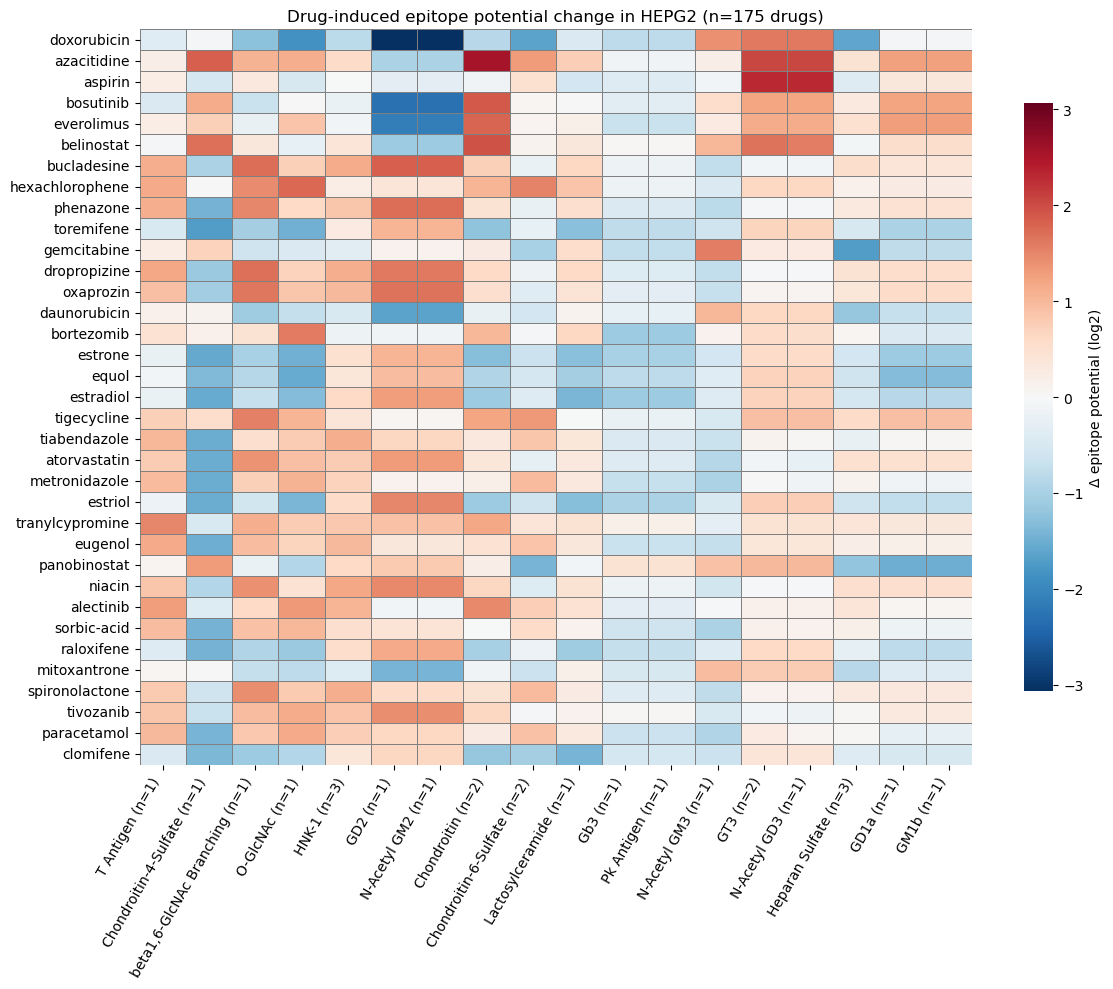

In [9]:
top_epi  = cand[cand.n_2x > 0].index[:18]
top_drug = d[top_epi].abs().max(axis=1).nlargest(35).index
hm = d.loc[top_drug, top_epi]

fig, ax = plt.subplots(figsize=(12, 10))
vmax = np.abs(hm.values).max()
sns.heatmap(hm, ax=ax, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Δ epitope potential (log2)', 'shrink': 0.8})
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_title(f'Drug-induced epitope potential change in {CELL} (n={len(d)} drugs)')
ax.set_xticklabels([f'{e} (n={cand.loc[e, "n_gene"]})' for e in top_epi])
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
savefig('fig_epitope_delta_hepg2')
plt.show()

## 所見

このセルは実行後に埋める。要点：

- **単一遺伝子・単一ステップのエピトープでは射影が恒等写像**なので、順序を直しても値は変わらない。
  変わるのは複数遺伝子 or 複数ステップのエピトープだけで、そこでは相関が大きく崩れる（負相関になる例もある）。
- **誤った順序は多遺伝子エピトープに偽の応答を作っていた**。Lewis 系がその代表。
- 候補表 `results/tables/drug_epitope_candidates_hepg2.csv` が wet 依頼の材料になる
  （薬剤名・エピトープ・向き・倍率）。